# imports

In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import re 

In [ ]:
df_news = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/news.csv")

# EDA

In [ ]:
print(df_news.shape)
print(df_news.info)

df_news.head()

Summary of key columns

In [ ]:
cols = [
    "article_count",
    "negative_count",
    "avg_sentiment_score",
    "avg_relevance_score",
    "max_relevance_score",
    "negative_ratio",
    "has_high_relevance_negative_news"
]

display(df_news[cols].describe())

,article_count,negative_count,avg_sentiment_score,avg_relevance_score,max_relevance_score,negative_ratio,has_high_relevance_negative_news
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,5.883832,0.737725,0.560833,3.653618,3.960359,0.104233,0.185629
std,10.184611,2.566049,0.562061,0.575915,0.752882,0.254986,0.389040
min,1.000000,0.000000,-1.000000,3.000000,3.000000,0.000000,0.000000
25%,1.000000,0.000000,0.186147,3.000000,3.000000,0.000000,0.000000
50%,2.000000,0.000000,0.800000,3.500000,4.000000,0.000000,0.000000
75%,5.000000,0.000000,1.000000,4.000000,5.000000,0.000000,0.000000
max,96.000000,33.000000,1.000000,5.000000,5.000000,1.000000,1.000000


Coverage of simple candidate thresholds

In [ ]:
threshold_summary = pd.DataFrame({
    "article_count >= 5": [df_news["article_count"].ge(5).mean()],
    "article_count >= 10": [df_news["article_count"].ge(10).mean()],
    "negative_count >= 1": [df_news["negative_count"].ge(1).mean()],
    "negative_count >= 2": [df_news["negative_count"].ge(2).mean()],
    "negative_ratio >= 0.10": [df_news["negative_ratio"].ge(0.10).mean()],
    "negative_ratio >= 0.20": [df_news["negative_ratio"].ge(0.20).mean()],
    "avg_sentiment_score <= 0.40": [df_news["avg_sentiment_score"].le(0.40).mean()],
    "has_high_relevance_negative_news = 1": [df_news["has_high_relevance_negative_news"].mean()],
}).T.reset_index()

threshold_summary.columns = ["candidate_rule", "share_of_rows"]
display(threshold_summary.sort_values("share_of_rows", ascending=False))

,candidate_rule,share_of_rows
0,article_count >= 5,0.306587
6,avg_sentiment_score <= 0.40,0.306587
2,negative_count >= 1,0.229940
4,negative_ratio >= 0.10,0.203593
7,has_high_relevance_negative_news = 1,0.185629
5,negative_ratio >= 0.20,0.156886
1,article_count >= 10,0.147305
3,negative_count >= 2,0.098204


Look at strongest negative-news cases

In [ ]:
display(
    df_news.sort_values(
        ["negative_count", "negative_ratio", "max_relevance_score"],
        ascending=False
    )[
        [
            "supplier_number",
            "Join_Year",
            "article_count",
            "negative_count",
            "negative_ratio",
            "avg_sentiment_score",
            "avg_relevance_score",
            "max_relevance_score",
            "has_high_relevance_negative_news"
        ]
    ].head(20)
)

,supplier_number,Join_Year,article_count,negative_count,negative_ratio,avg_sentiment_score,avg_relevance_score,max_relevance_score,has_high_relevance_negative_news
711,48948,2027,46,33,0.717391,-0.543478,4.141304,5.0,1
713,48980,2027,64,21,0.328125,-0.078125,4.003125,5.0,1
111,1340608,2027,96,21,0.218750,0.312500,4.302083,5.0,1
338,19768,2027,61,20,0.327869,0.114754,4.240984,5.0,1
307,165500,2027,25,19,0.760000,-0.600000,4.840000,5.0,1
532,38224,2027,30,18,0.600000,-0.400000,3.906667,5.0,1
424,31179,2027,56,17,0.303571,0.178571,4.285714,5.0,1
171,14529,2025,18,14,0.777778,-0.777778,3.805556,4.5,1
278,162506,2026,61,14,0.229508,0.213115,3.955738,5.0,1
56,12440,2027,33,13,0.393939,-0.212121,3.921212,5.0,1


Simple plots

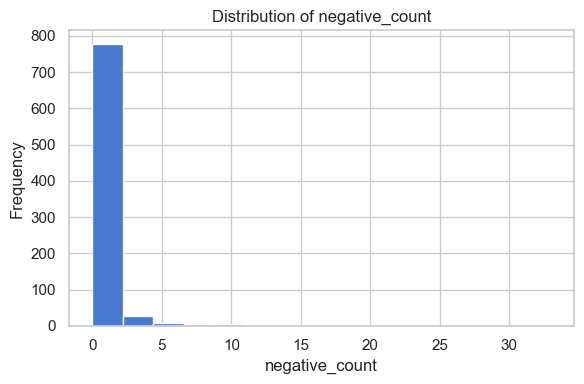

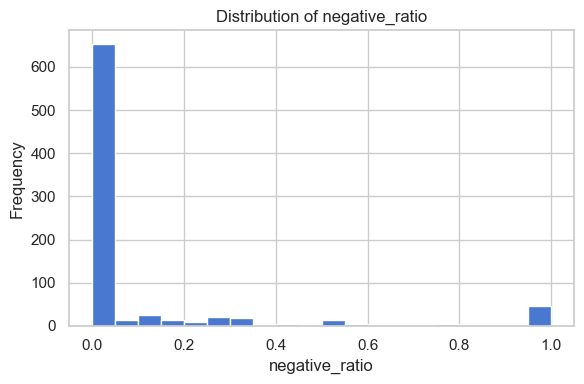

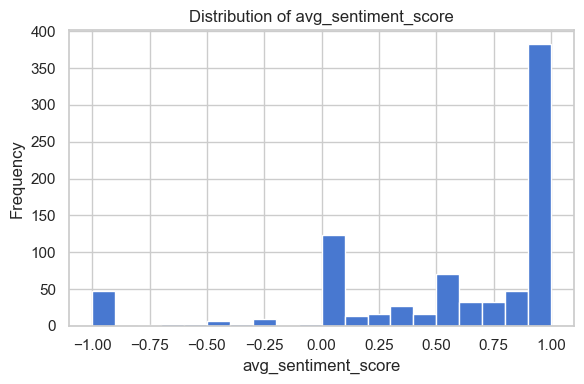

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df_news["negative_count"], bins=15)
plt.title("Distribution of negative_count")
plt.xlabel("negative_count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_news["negative_ratio"], bins=20)
plt.title("Distribution of negative_ratio")
plt.xlabel("negative_ratio")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_news["avg_sentiment_score"], bins=20)
plt.title("Distribution of avg_sentiment_score")
plt.xlabel("avg_sentiment_score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 6. Optional: test a few exploratory rule flags
#    Not final labels, just EDA for justification
# ------------------------------------------------------------
df_news["rule_neg_volume"] = (
    (df_news["article_count"] >= 5) &
    (df_news["negative_count"] >= 2)
).astype(int)

df_news["rule_neg_ratio"] = (
    (df_news["article_count"] >= 5) &
    (df_news["negative_ratio"] >= 0.20)
).astype(int)

df_news["rule_high_rel_neg"] = (
    df_news["has_high_relevance_negative_news"] == 1
).astype(int)

df_news["rule_poor_sentiment"] = (
    (df_news["article_count"] >= 5) &
    (df_news["avg_sentiment_score"] <= 0.40)
).astype(int)

rule_summary = pd.DataFrame({
    "rule_neg_volume": [df_news["rule_neg_volume"].mean()],
    "rule_neg_ratio": [df_news["rule_neg_ratio"].mean()],
    "rule_high_rel_neg": [df_news["rule_high_rel_neg"].mean()],
    "rule_poor_sentiment": [df_news["rule_poor_sentiment"].mean()],
}).T.reset_index()

rule_summary.columns = ["rule", "share_of_rows"]
display(rule_summary.sort_values("share_of_rows", ascending=False))

,rule,share_of_rows
2,rule_high_rel_neg,0.185629
3,rule_poor_sentiment,0.086228
0,rule_neg_volume,0.082635
1,rule_neg_ratio,0.056287
